# Linear Advection Equation in 1D with DG and SIAC Postprocessing

This notebook studies the one-dimensional linear advection equation

$$
u_t + a u_x = 0, \qquad x \in \Omega,
$$

with constant advection speed $a$. We use a discontinuous Galerkin (DG) method in space, explicit time stepping, and later apply SIAC postprocessing to the computed DG solution.

The main goals are:

- construct a modal DG approximation using orthonormal Legendre basis functions,
- evolve the solution using explicit time integrators such as Forward Euler and RK4,
- study the effect of noise in the DG approximation,
- apply SIAC postprocessing and compare filtered and unfiltered solutions.

## DG Weak Formulation

Let the domain be divided into cells

$$
I_j = [x_{j-\frac12}, x_{j+\frac12}],
$$

and map each cell to the reference interval $r \in [-1,1]$. On each cell, the DG approximation is written as

$$
u_h^j(x(r),t)
=
\sum_{n=0}^p u_n^j(t)\,\ell_n(r),
$$

where $\{\ell_n\}_{n=0}^p$ is an orthonormal Legendre basis on $[-1,1]$.

Multiplying the advection equation by a test function $v_h$, integrating over one cell, and integrating the flux term by parts gives

$$
\int_{I_j} (u_h)_t v_h \, dx
-
\int_{I_j} a u_h (v_h)_x \, dx
+
\widehat{f}_{j+\frac12} v_h^-
-
\widehat{f}_{j-\frac12} v_h^+
=
0.
$$

Here $\widehat{f}$ is a numerical flux. In this notebook we initially use the Lax--Friedrichs flux

$$
\widehat{f}(u^-,u^+)
=
\frac12\left(a u^- + a u^+\right)
-
\frac12 |a|\left(u^+ - u^-\right),
$$

which reduces to the standard upwind flux for linear advection.

## Time Stepping and CFL Condition

After spatial discretization, the DG method gives a system of ordinary differential equations

$$
\frac{d\mathbf{u}}{dt} = L(\mathbf{u}),
$$

where $L$ is the DG spatial operator.

We consider explicit time stepping methods such as Forward Euler and classical fourth-order Runge--Kutta (RK4). For a uniform mesh with cell size $h$, polynomial degree $p$, and advection speed $a$, we use the practical CFL estimate

$$
\Delta t
\leq
C_{\mathrm{CFL}}
\frac{h}{(2p+1)|a|}.
$$

The constants used here are conservative, non-spectral-radius-based choices. They are intended as safe defaults rather than sharp stability limits.

Typical choices are:

$$
C_{\mathrm{CFL}} =
\begin{cases}
0.5, & \text{Forward Euler}, \\
1.0, & \text{RK4}.
\end{cases}
$$

In the experiments below, an additional safety factor may be applied, and the time step is adjusted so that the final time is reached exactly.

In [23]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [24]:
import numpy as np
import matplotlib.pyplot as plt

from src.mesh import build_uniform_mesh
from src.projection import l2_project_mesh, add_modal_noise
from src.dg_solver import dg_rhs_advection
from src.time_integrators import forward_euler_step, rk4_step, time_integrator
from src.cfl import estimate_dt_advection, choose_time_step
from src.evaluation import evaluate_dg_solution
from src.metrics import linf_error, l2_error_dg, relative_l2_error_dg

In [25]:
# Wave speed
a = 2

# Total Time
T = 2

# time stepping method: rk4 or euler (forward_euler)
time_method = "rk4"

# Define the domain
xmin, xmax = -1, 1
domain = (-1, 1)

# DG setup
p = 2
order = p + 1
K = 32

# Exact function (periodic)
def exact_func(x):
    return np.sin(2*np.pi*x)

# create mesh
mesh = build_uniform_mesh(K=K, domain=domain)

# build initial projection
dg = l2_project_mesh(f=exact_func, p=p, mesh=mesh, num_quad=None)

# Define RHS wrapper
def rhs(u, t):
    return dg_rhs_advection(
        coeffs=u, 
        mesh=mesh, 
        p=p, 
        a=a
    )

# choose time stepping from CFL conditions
dt_est = estimate_dt_advection(mesh=mesh, p=p, a=a, method=time_method, safety=0.9)
dt, num_steps = choose_time_step(T=T, dt_est=dt_est)

print(f"dt = {dt}")
print(f"num_steps = {num_steps}")



dt = 0.0056179775280898875
num_steps = 356


In [26]:
time_tol = 1e-12

u = dg["coeffs"].copy()
t = 0.0

for n in range(num_steps):
    dt_step = min(dt, T - t)

    if dt_step <= time_tol:
        break

    u = time_integrator(rhs, u, t, dt_step, method=time_method)
    t += dt_step

# Snap final time to T if only roundoff remains
if abs(T - t) <= time_tol:
    t = T
else:
    raise RuntimeError(f"Time stepping stopped at t={t}, not T={T}.")

dg_final = dg.copy()
dg_final["coeffs"] = u
dg_final["t"] = t

In [27]:

# number of evaluation points per element/cell
ppe = 10

eval_grid, U_dg = evaluate_dg_solution(dg_final, points_per_cell=ppe)

t_final = dg_final["t"]

def exact_solution(x, t):
    return exact_func(x - a*t)

U_exact = exact_solution(eval_grid, t_final)

In [28]:

# pointwise Linf using plotting/evaluation grid
err_linf = linf_error(U_dg, U_exact)

# quadrature-based L2 errors
err_l2 = l2_error_dg(dg_final, exact_solution, t=dg_final["t"])
err_l2_rel = relative_l2_error_dg(dg_final, exact_solution, t=dg_final["t"])

print(f"Linf error       = {err_linf:.3e}")
print(f"L2 error         = {err_l2:.3e}")
print(f"Relative L2 error = {err_l2_rel:.3e}")

Linf error       = 9.807e-04
L2 error         = 2.972e-04
Relative L2 error = 2.972e-04


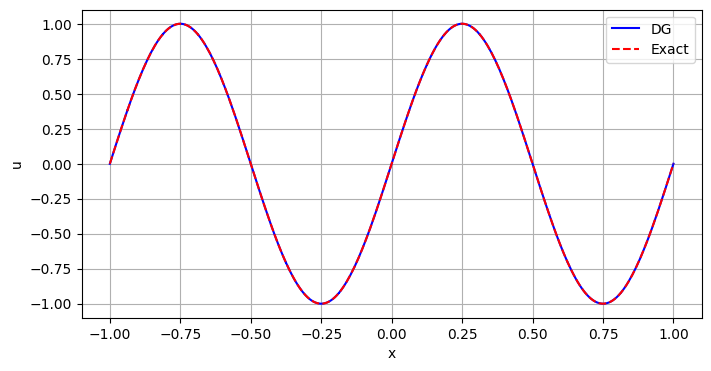

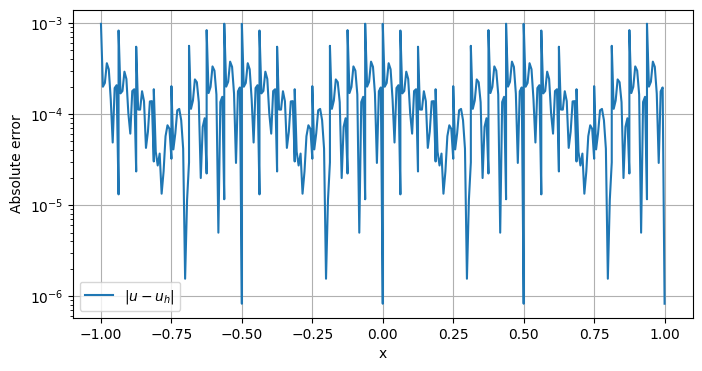

In [29]:


plt.figure(figsize=(8, 4))
plt.plot(eval_grid, U_dg, "b", label="DG")
plt.plot(eval_grid, U_exact, "r--", label="Exact")
plt.xlabel("x")
plt.ylabel("u")
plt.legend()
plt.grid(True)
plt.show()

abs_error = np.abs(U_dg - U_exact)

plt.figure(figsize=(8, 4))
plt.semilogy(eval_grid, abs_error, label=r"$|u-u_h|$")
plt.xlabel("x")
plt.ylabel("Absolute error")
plt.legend()
plt.grid(True)
plt.show()